# Noiseless_integrable_Traceout

In [1]:
import sys
sys.path.insert(0, '../../../src/')

import numpy as np
import qiskit as qk
import matplotlib.pyplot as plt
import multiprocessing as mp
import tensorflow as tf
import random
import pickle as pkl
import scipy

from src import *
from qiskit.quantum_info import Operator

from kraus_channels import isomery_to_kraus
from spectrum import *

#np.set_printoptions(threshold=sys.maxsize)
np.set_printoptions(precision=1)

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"




2025-10-13 11:25:25.208991: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Inspect spectrum

In [7]:
def integrable_circuit_tuned(n, L, couple):
    theta_list = [np.random.uniform(-np.pi, np.pi, n) for i in range(L)]
    sqrt_iSWAP = iSwapGate().power(1 / 2)
    tuned_coup = iSwapGate().power(couple)

    circuit = qk.QuantumCircuit(n)
    for i, theta in enumerate(theta_list):

        offset = i%2
        for j in range(n):
            circuit.rz(theta[j], j)

        for j in range((n - offset) // 2):
            if j + offset != 2:  # tune the coupling in the middle of the chain
                circuit.append(sqrt_iSWAP, [2 * j + offset, 2 * j + 1 + offset])
            else:
                circuit.append(tuned_coup, [2 * j + offset, 2 * j + 1 + offset])
            

    return circuit

In [7]:
from kraus_channels import KrausMap
from quantum_channel import DilutedChannel

csr_list = []
for i in range(10):
    np.random.seed(42 + i) # different seeds for each realization|
    circuit_target = integrable_circuit_tuned(5, 5, 1/100)
    U = Operator(circuit_target).data

    kraus_map = isomery_to_kraus(U, 2)
    spectrum = channel_spectrum(kraus_map)    
    SO = np.array(kraus_map.superoperator)
    np.savetxt(f"dump/unitary/SO_{i}.txt", SO, fmt="%.17f")


In [8]:
csr_list = []
for i in range(10):
    np.random.seed(42 + i) # different seeds for each realization|
    circuit_target = integrable_circuit_tuned(5, 5, 1/8)
    U = Operator(circuit_target).data

    kraus_map = isomery_to_kraus(U, 2)
    spectrum = channel_spectrum(kraus_map)    
    SO = np.array(kraus_map.superoperator)
    np.savetxt(f"dump/weak_coup/SO_{i}.txt", SO, fmt="%.17f")

In [ ]:
csr_list = []
for i in range(10):
    np.random.seed(42 + i) # different seeds for each realization|
    circuit_target = integrable_circuit_tuned(5, 5, 1/2)
    U = Operator(circuit_target).data

    kraus_map = isomery_to_kraus(U, 2)
    spectrum = channel_spectrum(kraus_map)    
    SO = np.array(kraus_map.superoperator)
    np.savetxt(f"dump/strong_coup/SO_{i}.txt", SO, fmt="%.17f")

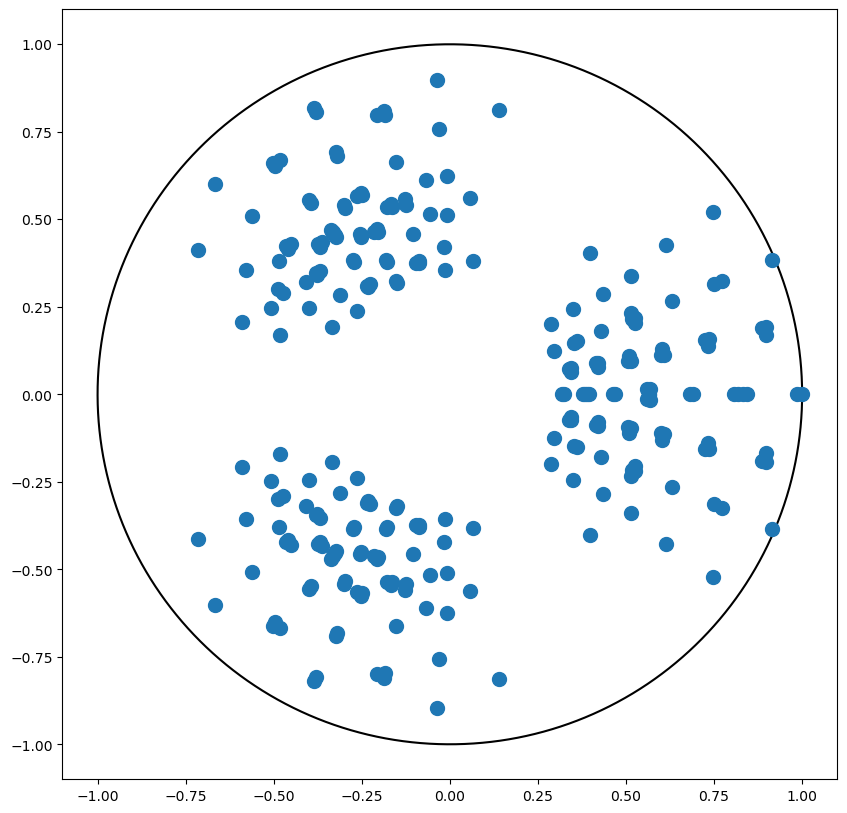

In [5]:
spectrum.plot_circle()
spectrum.plot()